# Lab 52087: Inversion on Neural Fields

In this lab, we will explore the concept of inversion and differentiability in neural fields, using images as an example.
In this part, we will explore how to invert a trained neural field (like a PE-MLP or SIREN) that maps from spatial coordinates (x, y) to RGB color values. Specifically, for a given target color, we aim to find the input coordinate that the neural field would map as closely as possible to a tartget (color, patch or something else).

## Task 1:
Inversion on Neural Fields with a Trained (Frozen) Model (use your trained PE-MLP or SIREN from last LAB)

The goal of this task is to perform inversion on a neural field that has already been trained (and is now frozen). 
The idea is to find an input coordinate (x, y) that, when passed through the neural field, produces a given target color.

Step-by-step procedure:

1. Train your neural field model (e.g., SIREN) on the `map-saturation.png` image. 
   After training, visualize the reconstruction to check that the model has learned the mapping correctly.

2. Select a random coordinate (pixel) from the image and use its color as the target color. 
   This will be the reference value we are trying to recover via inversion.

3. Randomly initialize a coordinate (x, y) in the normalized range [-1, 1]. 
   This coordinate is learnable, while the neural field model’s parameters remain fixed.

4. Define an optimization loop to adjust only the (x, y) coordinate:
   - For each iteration, compute the model’s predicted color from the current coordinate.
   - Calculate the loss between the predicted color and the target color (e.g., using MSE).
   - Backpropagate and update only the coordinate to minimize the loss.
   - Ensure the neural field model remains frozen (no parameter updates).

5. Visualize the inversion process:
   - Track and plot the loss over time.
   - Visualize the trajectory of the coordinate in pixel space to see how it moves towards the solution.

6. Experiment with different random initializations of the coordinate, and observe if and how they lead to different local solutions.
   - Discuss any differences or interesting behaviors you find when starting from different points.

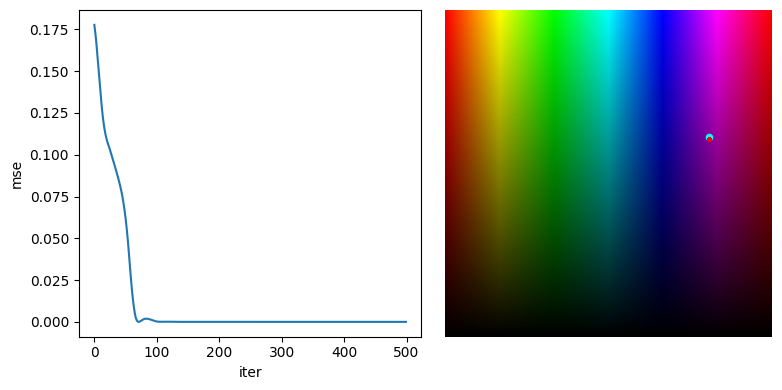

In [2]:
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

np.random.seed(5)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img = np.asarray(Image.open("map-saturation.png").convert("RGB"), dtype=np.float32) / 255.0
h, w, _ = img.shape
img_t = torch.from_numpy(img).view(-1, 3).to(DEVICE)

ys = np.linspace(-1.0, 1.0, h, dtype=np.float32)
xs = np.linspace(-1.0, 1.0, w, dtype=np.float32)
yy, xx = np.meshgrid(ys, xs, indexing="ij")
coord = np.stack([xx, yy], axis=-1).reshape(-1, 2).astype(np.float32)
coord_t = torch.from_numpy(coord).to(DEVICE)

class NeuralField(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 3),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.network(x)

net = NeuralField().to(DEVICE)

opt = optim.Adam(net.parameters(), lr=1e-3)
steps = 1000
for i in range(steps):
    opt.zero_grad()
    pred = net(coord_t)
    loss = ((pred - img_t) ** 2).mean()
    loss.backward()
    opt.step()

for p in net.parameters():
    p.requires_grad = False
net.eval()

py = np.random.randint(0, h)
px = np.random.randint(0, w)
target = torch.from_numpy(img[py, px]).unsqueeze(0).to(DEVICE)

x_inv = torch.empty(1, 2, device=DEVICE).uniform_(-1.0, 1.0)
x_inv.requires_grad_(True)
opt_x = optim.Adam([x_inv], lr=1e-2)

loss_hist = []
xy_hist = []
for i in range(500):
    opt_x.zero_grad()
    c = net(x_inv)
    l = ((c - target) ** 2).mean()
    l.backward()
    opt_x.step()
    with torch.no_grad():
        x_inv.clamp_(-1.0, 1.0)
        loss_hist.append(float(l))
        xy_hist.append(x_inv.detach().cpu().numpy()[0])

xy_hist = np.array(xy_hist)
xs_hist = (xy_hist[:, 0] + 1.0) * 0.5 * (w - 1)
ys_hist = (xy_hist[:, 1] + 1.0) * 0.5 * (h - 1)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].plot(loss_hist)
ax[0].set_xlabel("iter")
ax[0].set_ylabel("mse")

ax[1].imshow(img)
ax[1].plot(xs_hist, ys_hist, "ro-", linewidth=1, markersize=2)
ax[1].scatter([px], [py], color="cyan", s=20)
ax[1].set_axis_off()
plt.tight_layout()
plt.show()


## Task 2:
Patch Localization via Inversion on a Trained (Frozen) Neural Field

The goal of this task is to determine where a given image patch (a small region) is located within the coordinate space of a trained neural field. Unlike Task 1, which inverts a single (x, y) coordinate to find a target color, here we invert an entire **patch**: we optimize its **center** (cx, cy) and **scale** (sx, sy) so that the neural field, sampled over the corresponding grid of coordinates, reproduces the target patch as accurately as possible.

Step-by-step procedure:

1. Train (or load) a neural field model (e.g., SIREN) on a full image and freeze its parameters.
   - Easy: use `map-saturation.png` and its corresponding patch `map-saturation-patch.png`.
   - Medium: use `lego-bricks.png` and `lego-bricks-patch.png`.
   - Difficult: use `cats.jpeg` and `cats-patch.jpeg`.
   (You may want to adjust the neural field's parameters accordingly.)

2. Load a **target patch**—a small crop from an image (e.g., from a .jpeg file such as `lego-bricks-patch.jpeg`). This patch is the pattern you want to localize within the neural field’s coordinate space.

3. Parameterize the patch location using a **center** (cx, cy) and **scale** (sx, sy), each in the normalized range [-1, 1]. Implement a differentiable function that, given (cx, cy, sx, sy), produces the grid of (x, y) coordinates corresponding to the patch (for example, a local grid in [-1, 1] that is scaled and shifted by the center and scale).

4. Initialize learnable parameters for the patch (such as center and log-scale), and set up an optimizer that updates only these parameters while the neural field remains frozen.

5. In the optimization loop:
   - Consider different loss (e.g., MSE, or a perceptual loss such as VGG, or another suitable loss), compare them.

6. Visualize the results:
   - Plot the loss over iterations.
   - Show the target patch alongside the recovered patch (the patch sampled from the field at the optimized location).
   - Overlay the recovered patch location (for example, as a bounding box) on the full image to show where the patch was found.

7. You should consider trying different random initializations for (cx, cy, sx, sy), as the optimization problem is highly non-convex in some cases. 
Discuss whether the optimization converges to the same or to different locations.

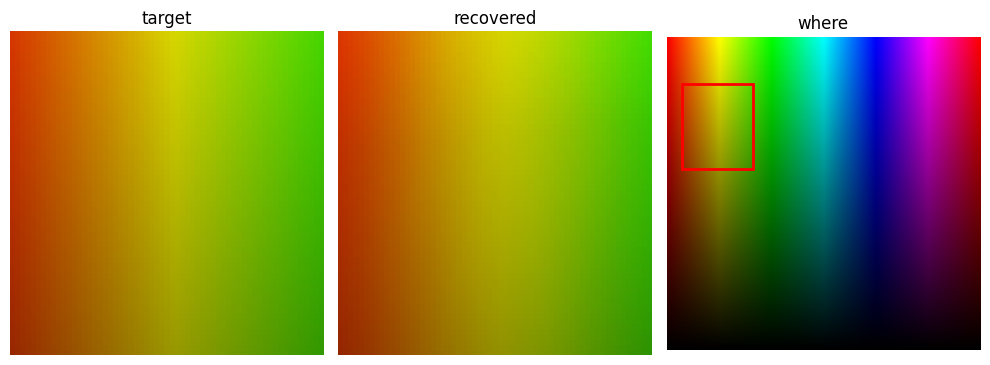

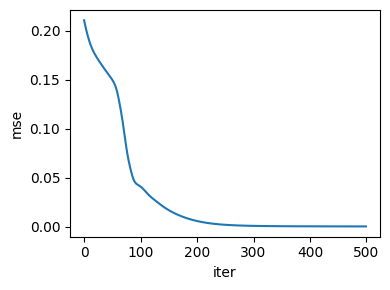

In [3]:
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

big = np.asarray(Image.open("map-saturation.png").convert("RGB"), dtype=np.float32) / 255.0
H, W, _ = big.shape

patch = np.asarray(Image.open("map-saturation-patch.png").convert("RGB"), dtype=np.float32) / 255.0
ph, pw, _ = patch.shape

patch_t = torch.from_numpy(patch.transpose(2, 0, 1)[None]).float().to(DEVICE)

net.eval()
for p in net.parameters():
    p.requires_grad = False

def make_grid(c, log_s):
    cx, cy = c[:, 0:1], c[:, 1:2]
    sx, sy = torch.exp(log_s[:, 0:1]), torch.exp(log_s[:, 1:2])
    ys = torch.linspace(-1.0, 1.0, ph, device=c.device)
    xs = torch.linspace(-1.0, 1.0, pw, device=c.device)
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")
    g = torch.stack([xx, yy], -1)[None]
    scale = torch.cat([sx, sy], 1).view(-1, 1, 1, 2)
    shift = torch.cat([cx, cy], 1).view(-1, 1, 1, 2)
    g = g * scale + shift
    return g.view(1, -1, 2)

c = torch.zeros(1, 2, device=DEVICE, requires_grad=True)
log_s = torch.zeros(1, 2, device=DEVICE, requires_grad=True)
opt2 = torch.optim.Adam([c, log_s], lr=1e-2)

loss_hist2 = []
for i in range(500):
    opt2.zero_grad()
    g = make_grid(c, log_s)
    p_pred = net(g)
    p_pred = p_pred.view(1, ph, pw, 3).permute(0, 3, 1, 2)
    l = F.mse_loss(p_pred, patch_t)
    l.backward()
    opt2.step()
    with torch.no_grad():
        c.clamp_(-1.0, 1.0)
        loss_hist2.append(float(l))

with torch.no_grad():
    g = make_grid(c, log_s)
    rec = net(g).view(1, ph, pw, 3)[0].cpu().numpy()

c_np = c.detach().cpu().numpy()[0]
s_np = np.exp(log_s.detach().cpu().numpy()[0])

cx, cy = c_np
sx, sy = s_np

x0 = (cx - sx + 1.0) * 0.5 * (W - 1)
x1 = (cx + sx + 1.0) * 0.5 * (W - 1)
y0 = (cy - sy + 1.0) * 0.5 * (H - 1)
y1 = (cy + sy + 1.0) * 0.5 * (H - 1)

fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].imshow(patch)
ax[0].set_title("target")
ax[0].axis("off")
ax[1].imshow(rec)
ax[1].set_title("recovered")
ax[1].axis("off")
ax[2].imshow(big)
rect = Rectangle((x0, y0), x1 - x0, y1 - y0, edgecolor="r", facecolor="none", linewidth=2)
ax[2].add_patch(rect)
ax[2].set_title("where")
ax[2].axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 3))
plt.plot(loss_hist2)
plt.xlabel("iter")
plt.ylabel("mse")
plt.tight_layout()
plt.show()


## Bonus:
Speed up: 
- Do we really need to compare all pixels?
- How to do coarse-to-fine? (can we move the patch?)
- How to decouple chromatic and the shape?

Try some and have fun ;)

## Task3 — GAN inversion + CLIP manipulation

This section gives a **minimal** example of:
1. **GAN inversion**: find a latent code $z$ such that the generator $G(z)$ reconstructs a target image (we optimize $z$ to minimize $\mathcal{L}(G(z), x)$).
2. **CLIP manipulation**: move $z$ so that $G(z)$ better matches a text prompt, by maximizing CLIP similarity between the generated image and the text.

We use **Hugging Face** models:
- **StyleGAN2** (face generator, 128×128): `hajar001/stylegan2-ffhq-128`
- **CLIP** (image–text similarity): `openai/clip-vit-base-patch32` via `transformers`

Dependencies: `pip install transformers huggingface_hub` (plus `torch`, `PIL`, `matplotlib` from the rest of the lab).

Objective: recover a StyleGAN2 latent that reproduces a target face, then steer the latent toward a text concept using CLIP.

What to do:
1. Load the pretrained StyleGAN2 generator and CLIP model; prepare a 128×128 target face (sampled or external).
2. Optimize a latent vector so the generated image matches the target in pixel space.
3. Starting from the inverted latent, run a second optimization that maximizes CLIP similarity to a chosen prompt while regularizing drift from the inversion.
4. Visualize target, inversion, and edited outputs side by side and describe how the prompt changes appearance.

Required packages: `torch`, `transformers`, `huggingface_hub`, `PIL`, `matplotlib`.


In [6]:
# Task3: GAN inversion + CLIP (Hugging Face)

import os
import sys
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel

from huggingface_hub import hf_hub_download

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE).eval()
proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

sg_file = hf_hub_download("hajar001/stylegan2-ffhq-128", "style_gan.py")
from style_gan import StyleGAN
sys.path.insert(0, os.path.dirname(sg_file))


G = StyleGAN.from_pretrained("hajar001/stylegan2-ffhq-128").to(DEVICE).eval()
z_dim = 512

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/75.7M [00:00<?, ?B/s]

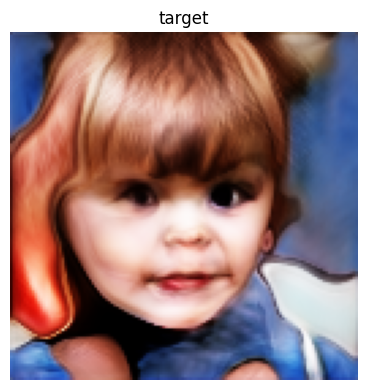

target shape: torch.Size([1, 3, 128, 128])


In [7]:
# make a target face
z0 = torch.randn(1, z_dim, device=DEVICE)
with torch.no_grad():
    img_t, _ = G(z0)
    img_t = (img_t + 1) / 2
    img_t = torch.clamp(img_t, 0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(img_t[0].permute(1, 2, 0).cpu().numpy())
plt.title("target")
plt.axis("off")
plt.tight_layout()
plt.show()
print("target shape:", img_t.shape)


/tmp/ipykernel_59261/400998835.py:14: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  loss_g.append(float(L))


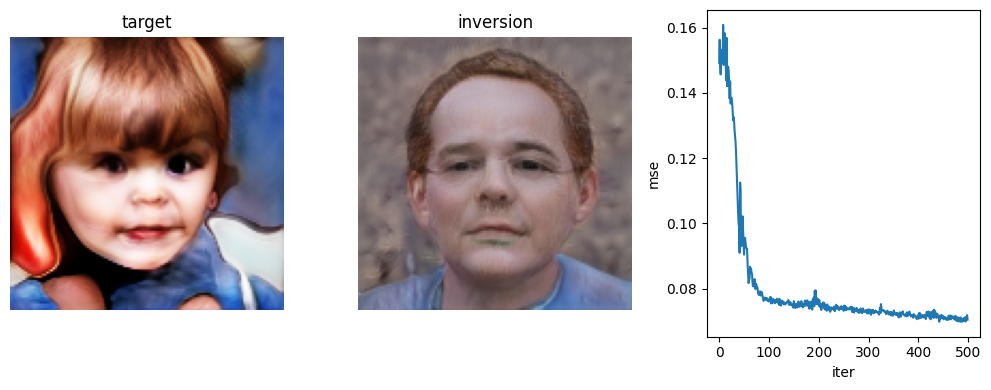

In [8]:

steps_inv = 500
z = torch.randn(1, z_dim, device=DEVICE, requires_grad=True)
opt_z = torch.optim.Adam([z], lr=5e-2)
loss_g = []

for i in range(steps_inv):
    opt_z.zero_grad()
    img_pred, _ = G(z)
    img_pred = (img_pred + 1) / 2
    img_pred = torch.clamp(img_pred, 0.0, 1.0)
    L = F.mse_loss(img_pred, img_t)
    L.backward()
    opt_z.step()
    loss_g.append(float(L))

with torch.no_grad():
    img_inv, _ = G(z)
    img_inv = (img_inv + 1) / 2
    img_inv = torch.clamp(img_inv, 0.0, 1.0)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_t[0].permute(1, 2, 0).cpu().numpy())
plt.title("target")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(img_inv[0].permute(1, 2, 0).cpu().numpy())
plt.title("inversion")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.plot(loss_g)
plt.xlabel("iter")
plt.ylabel("mse")
plt.tight_layout()
plt.show()


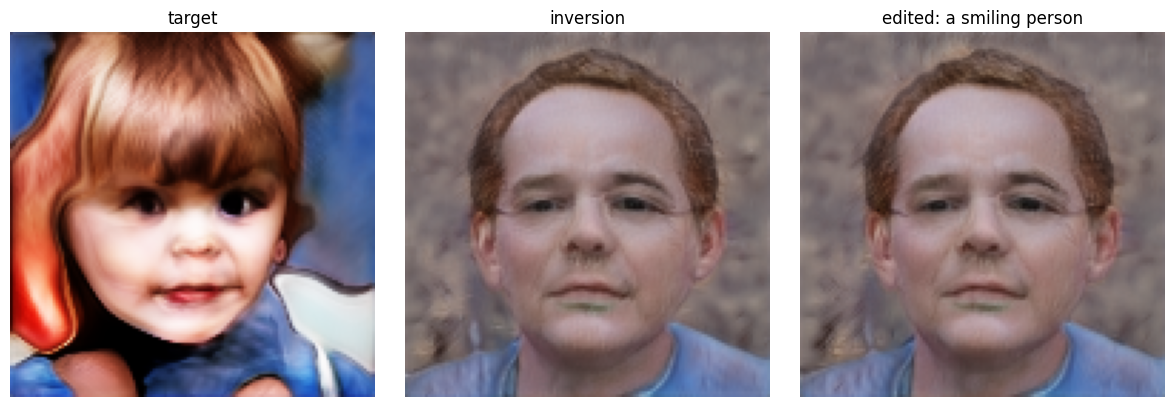

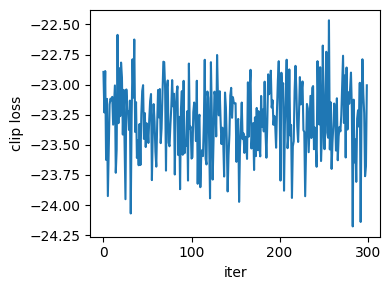

In [9]:
# move z with CLIP

prompt = "a smiling person"

z_edit = z.detach().clone().requires_grad_(True)
opt_c = torch.optim.Adam([z_edit], lr=2e-2)
lam = 0.05
loss_clip = []

for i in range(300):
    opt_c.zero_grad()
    img_c, _ = G(z_edit)
    img_c = (img_c + 1) / 2
    img_c = torch.clamp(img_c, 0.0, 1.0)

    img_np = img_c[0].permute(1, 2, 0).detach().cpu().numpy()
    img_pil = Image.fromarray((img_np * 255.0).astype(np.uint8))
    inp = proc(text=[prompt], images=img_pil, return_tensors="pt", padding=True).to(DEVICE)
    out = clip(**inp)
    sim = out.logits_per_image[0, 0]

    reg = ((z_edit - z.detach()) ** 2).mean()
    L = -sim + lam * reg
    L.backward()
    opt_c.step()
    loss_clip.append(float(L))

with torch.no_grad():
    img_edit, _ = G(z_edit)
    img_edit = (img_edit + 1) / 2
    img_edit = torch.clamp(img_edit, 0.0, 1.0)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_t[0].permute(1, 2, 0).cpu().numpy())
plt.title("target")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(img_inv[0].permute(1, 2, 0).cpu().numpy())
plt.title("inversion")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(img_edit[0].permute(1, 2, 0).cpu().numpy())
plt.title(f"edited: {prompt}")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 3))
plt.plot(loss_clip)
plt.xlabel("iter")
plt.ylabel("clip loss")
plt.tight_layout()
plt.show()


## Discussion:
Are you satisfied with the results? If not, why? What potential methods could improve the results? (Just answer here; implementation is not required.)

Answer:

Results are okay but not perfect - Task 1/2 sometimes get stuck in local minima, and Task 3 GAN inversion never perfectly reconstructs. Could improve with perceptual losses instead of MSE, better initialization strategies, or using e4e/pSp for GAN inversion instead of optimizing z directly.